In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [24]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [25]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [62]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4',  'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    1231
1     381
Name: count, dtype: int64


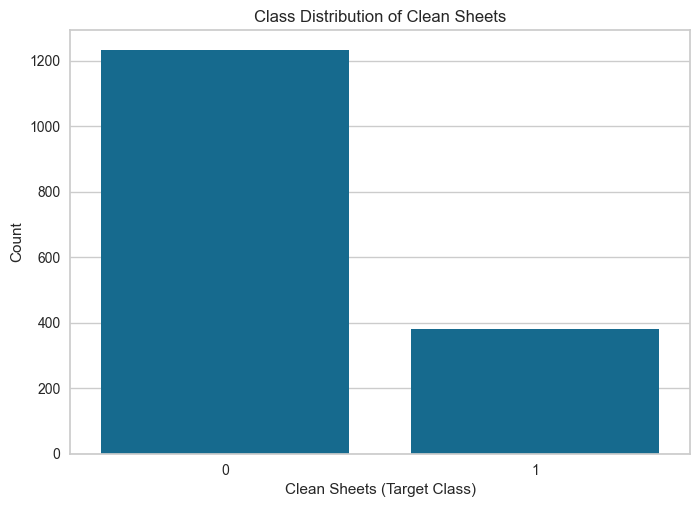

In [ ]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [ ]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 815, number of negative: 815
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18088
[LightGBM] [Info] Number of data points in the train set: 1630, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1612, 113)"
4,Transformed data shape,"(2114, 23)"
5,Transformed train set shape,"(1630, 23)"
6,Transformed test set shape,"(484, 23)"
7,Numeric features,111
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5869,0.5924,0.5084,0.2901,0.3682,0.0959,0.1038,1.1330
ridge,Ridge Classifier,0.5878,0.5916,0.5085,0.2908,0.3688,0.0970,0.1050,0.9800
lda,Linear Discriminant Analysis,0.5825,0.5876,0.4902,0.2830,0.3576,0.0820,0.0882,0.8500
svm,SVM - Linear Kernel,0.5647,0.5690,0.5236,0.2756,0.3603,0.0754,0.0862,1.0410
xgboost,Extreme Gradient Boosting,0.6986,0.5652,0.1761,0.2817,0.2124,0.0425,0.0443,1.6360
lightgbm,Light Gradient Boosting Machine,0.7137,0.5637,0.1356,0.2827,0.1795,0.0348,0.0384,1.2940
et,Extra Trees Classifier,0.6951,0.5572,0.1276,0.2139,0.1571,-0.0053,-0.0095,1.0810
gbc,Gradient Boosting Classifier,0.7021,0.5507,0.1536,0.2686,0.1935,0.0300,0.0312,1.4700
rf,Random Forest Classifier,0.6827,0.5470,0.0977,0.1726,0.1235,-0.0470,-0.0524,1.2790
nb,Naive Bayes,0.5310,0.5373,0.5171,0.2547,0.3400,0.0367,0.0447,1.0220


In [ ]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [ ]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5841,0.5248,0.5000,0.2766,0.3562,0.0851,0.0932
1,0.6195,0.6167,0.5926,0.3333,0.4267,0.1741,0.1902
2,0.7080,0.7799,0.7778,0.4375,0.5600,0.3661,0.4001
3,0.5487,0.5568,0.4444,0.2500,0.3200,0.0204,0.0223
4,0.5929,0.5663,0.5185,0.2979,0.3784,0.1075,0.1166
5,0.4956,0.5409,0.5556,0.2500,0.3448,0.0228,0.0276
6,0.5398,0.5633,0.5185,0.2642,0.3500,0.0489,0.0556
7,0.6106,0.6813,0.5926,0.3265,0.4211,0.1632,0.1797
8,0.5357,0.5452,0.5385,0.2593,0.3500,0.0533,0.0620


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [ ]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                 importance_getter='auto',
           

## DEF


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


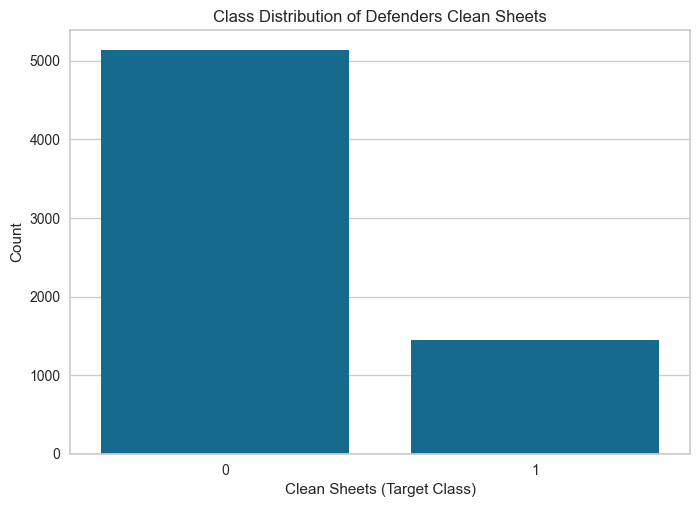

In [64]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [65]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3421, number of negative: 3421
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.112829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22689
[LightGBM] [Info] Number of data points in the train set: 6842, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 113)"
4,Transformed data shape,"(8814, 23)"
5,Transformed train set shape,"(6842, 23)"
6,Transformed test set shape,"(1972, 23)"
7,Numeric features,111
8,Rows with missing values,0.0%
9,Preprocess,True


In [66]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8437,0.8376,0.4401,0.7447,0.5519,0.4650,0.4892,1.3550
rf,Random Forest Classifier,0.8259,0.8035,0.2934,0.7670,0.4224,0.3443,0.4000,2.0370
xgboost,Extreme Gradient Boosting,0.8229,0.7966,0.3578,0.6878,0.4692,0.3755,0.4052,1.1800
lightgbm,Light Gradient Boosting Machine,0.8050,0.7765,0.2240,0.6654,0.3339,0.2518,0.3037,1.3890
knn,K Neighbors Classifier,0.5801,0.6871,0.7285,0.3083,0.4329,0.1799,0.2213,1.5800
gbc,Gradient Boosting Classifier,0.7774,0.6681,0.0476,0.4322,0.0840,0.0437,0.0792,2.9080
lda,Linear Discriminant Analysis,0.5781,0.6070,0.5580,0.2744,0.3677,0.1040,0.1183,1.0710
ridge,Ridge Classifier,0.5801,0.6062,0.5510,0.2741,0.3658,0.1028,0.1163,0.9580
lr,Logistic Regression,0.5781,0.6059,0.5530,0.2734,0.3657,0.1018,0.1154,5.0610
ada,Ada Boost Classifier,0.7225,0.6026,0.1894,0.2948,0.2288,0.0703,0.0733,1.4230


In [67]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [68]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6377,0.5989,0.4158,0.2800,0.3347,0.0986,0.1023
1,0.6304,0.6374,0.4700,0.2866,0.3561,0.1178,0.1249
2,0.6174,0.6186,0.5248,0.2928,0.3759,0.1309,0.1425
3,0.6391,0.5944,0.3960,0.2759,0.3252,0.0895,0.0923
4,0.6457,0.6503,0.5446,0.3198,0.4029,0.1746,0.1871
5,0.6696,0.6637,0.5248,0.3376,0.4109,0.1960,0.2052
6,0.6587,0.6197,0.3762,0.2879,0.3262,0.1030,0.1047
7,0.6109,0.6315,0.4554,0.2706,0.3395,0.0884,0.0944
8,0.6630,0.6419,0.4059,0.3015,0.3460,0.1257,0.1282


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [69]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [ ]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

## MID


clean_sheets
0    5447
1    1629
Name: count, dtype: int64


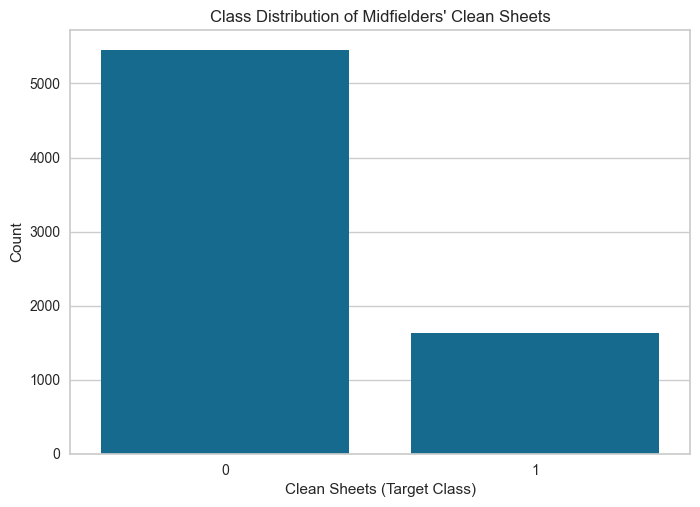

In [76]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [77]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(7076, 113)"
4,Transformed data shape,"(9405, 23)"
5,Transformed train set shape,"(7282, 23)"
6,Transformed test set shape,"(2123, 23)"
7,Numeric features,111
8,Preprocess,True
9,Imputation type,simple


In [78]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:12:10
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8112,0.8087,0.3833,0.6575,0.4825,0.3769,0.3984,1.8790
rf,Random Forest Classifier,0.8108,0.7896,0.2904,0.7244,0.4130,0.3243,0.3732,3.6060
xgboost,Extreme Gradient Boosting,0.7929,0.7580,0.3096,0.5962,0.4070,0.2967,0.3203,1.7090
lightgbm,Light Gradient Boosting Machine,0.7929,0.7495,0.2307,0.6390,0.3376,0.2462,0.2917,1.8420
knn,K Neighbors Classifier,0.5647,0.6846,0.7254,0.3105,0.4347,0.1654,0.2046,2.9560
gbc,Gradient Boosting Classifier,0.7678,0.6649,0.0632,0.4960,0.1100,0.0596,0.1046,3.2570
lr,Logistic Regression,0.5920,0.6227,0.5930,0.3036,0.4012,0.1388,0.1566,3.4860
ridge,Ridge Classifier,0.5924,0.6225,0.5947,0.3042,0.4022,0.1401,0.1581,2.4880
lda,Linear Discriminant Analysis,0.5899,0.6209,0.5886,0.3011,0.3981,0.1344,0.1517,1.2190
ada,Ada Boost Classifier,0.7248,0.6038,0.1781,0.3308,0.2267,0.0787,0.0862,1.7840


In [86]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [80]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6391,0.6030,0.3596,0.2789,0.3142,0.0746,0.0757
1,0.6270,0.6313,0.5526,0.3198,0.4051,0.1608,0.1736
2,0.6552,0.6829,0.5439,0.3425,0.4203,0.1926,0.2031
3,0.6303,0.6342,0.5351,0.3194,0.4000,0.1568,0.1677
4,0.6990,0.6834,0.5000,0.3826,0.4335,0.2334,0.2373
5,0.6424,0.6315,0.4298,0.3043,0.3564,0.1187,0.1221
6,0.6505,0.6487,0.5175,0.3333,0.4055,0.1741,0.1826
7,0.6364,0.6235,0.4298,0.2988,0.3525,0.1109,0.1145
8,0.6000,0.6054,0.4123,0.2640,0.3219,0.0572,0.0601


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [84]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [87]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

# Yellow Cards


In [88]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    1492
1     120
Name: count, dtype: int64


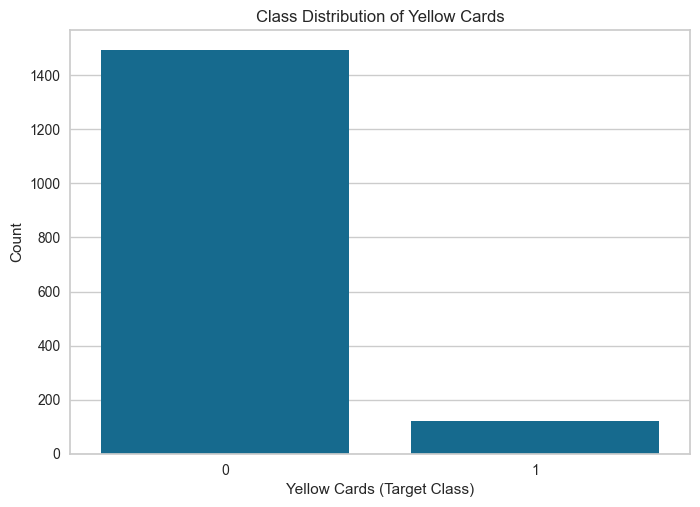

In [99]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [90]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 991, number of negative: 991
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19230
[LightGBM] [Info] Number of data points in the train set: 1982, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(2466, 24)"
5,Transformed train set shape,"(1982, 24)"
6,Transformed test set shape,"(484, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


In [91]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9211,0.5376,0.0000,0.0000,0.0000,-0.0069,-0.0083,1.5190
knn,K Neighbors Classifier,0.5559,0.5304,0.5125,0.0849,0.1454,0.0206,0.0375,1.1630
xgboost,Extreme Gradient Boosting,0.9193,0.5214,0.0583,0.3500,0.0986,0.0766,0.1154,1.1970
dt,Decision Tree Classifier,0.8458,0.5213,0.1403,0.0992,0.1140,0.0331,0.0345,0.9380
qda,Quadratic Discriminant Analysis,0.8201,0.5204,0.0958,0.0580,0.0694,-0.0213,-0.0219,1.0690
gbc,Gradient Boosting Classifier,0.9220,0.5200,0.0236,0.1500,0.0404,0.0295,0.0451,1.8340
lightgbm,Light Gradient Boosting Machine,0.9175,0.5178,0.0111,0.1000,0.0200,0.0043,0.0138,1.4030
et,Extra Trees Classifier,0.9193,0.5168,0.0000,0.0000,0.0000,-0.0105,-0.0152,1.1890
dummy,Dummy Classifier,0.9255,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.2470
lr,Logistic Regression,0.5833,0.4976,0.4042,0.0730,0.1235,-0.0021,0.0004,5.9730


In [ ]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [96]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6106,0.5119,0.3750,0.0714,0.1200,0.0012,0.0019
1,0.7522,0.5280,0.2500,0.0833,0.1250,0.0210,0.0254
2,0.9027,0.6732,0.1250,0.2000,0.1538,0.1051,0.1084
3,0.6460,0.5952,0.3750,0.0789,0.1304,0.0153,0.0226
4,0.4956,0.6020,0.5556,0.0862,0.1493,0.0132,0.0249
5,0.7788,0.5737,0.3333,0.1364,0.1935,0.0908,0.1030
6,0.6549,0.4679,0.2222,0.0588,0.0930,-0.0377,-0.0505
7,0.9204,0.5331,0.1111,0.5000,0.1818,0.1574,0.2084
8,0.6250,0.3167,0.1250,0.0278,0.0455,-0.0809,-0.1167


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [97]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                              

## DEF


yellow_cards
0    5581
1     992
Name: count, dtype: int64


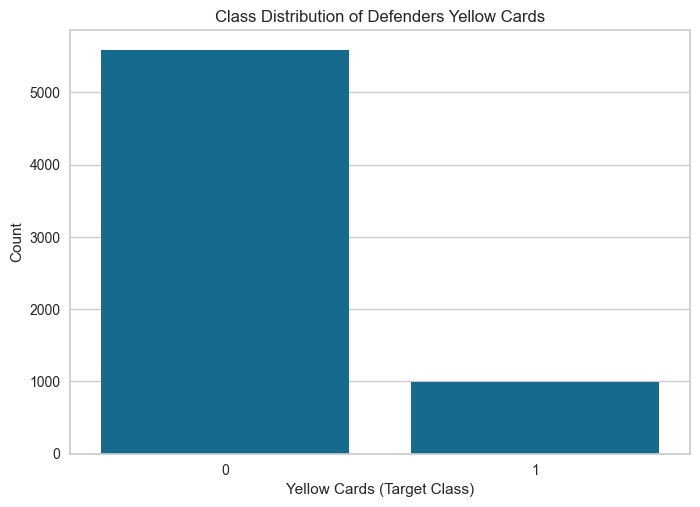

In [98]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [100]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3710, number of negative: 3710
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.209255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23742
[LightGBM] [Info] Number of data points in the train set: 7420, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(9392, 24)"
5,Transformed train set shape,"(7420, 24)"
6,Transformed test set shape,"(1972, 24)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


In [101]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8420,0.5722,0.0231,0.2649,0.0421,0.0168,0.0342,1.6320
xgboost,Extreme Gradient Boosting,0.8381,0.5687,0.0490,0.2731,0.0826,0.0407,0.0584,1.8710
gbc,Gradient Boosting Classifier,0.8474,0.5588,0.0029,0.0667,0.0055,0.0005,0.0003,3.6470
rf,Random Forest Classifier,0.8381,0.5431,0.0274,0.2817,0.0478,0.0147,0.0303,3.3570
ada,Ada Boost Classifier,0.8035,0.5417,0.0778,0.1739,0.1029,0.0125,0.0146,1.7880
et,Extra Trees Classifier,0.8350,0.5405,0.0606,0.2826,0.0988,0.0486,0.0666,1.9510
nb,Naive Bayes,0.4899,0.5392,0.5648,0.1610,0.2505,0.0205,0.0297,2.1230
qda,Quadratic Discriminant Analysis,0.5318,0.5332,0.4985,0.1607,0.2430,0.0194,0.0260,1.4090
lr,Logistic Regression,0.5323,0.5238,0.4870,0.1587,0.2393,0.0152,0.0197,2.4940
ridge,Ridge Classifier,0.5336,0.5237,0.4884,0.1595,0.2404,0.0167,0.0216,2.2340


In [105]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

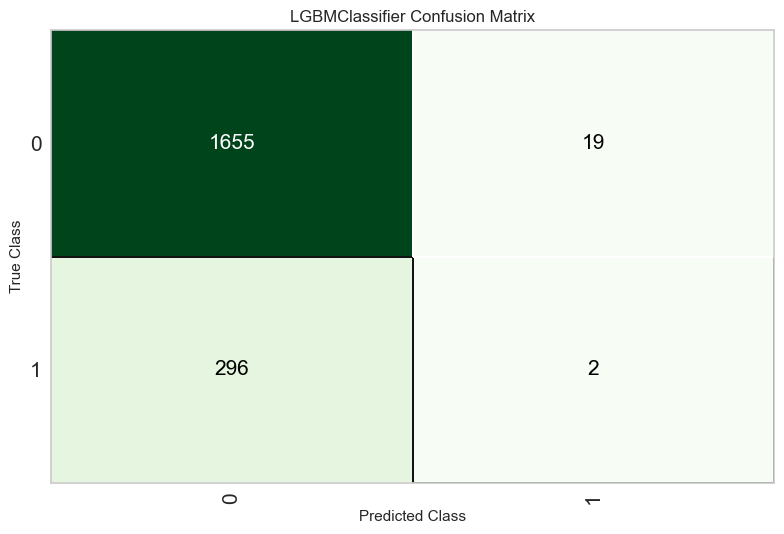

In [107]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [102]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8482,0.6003,0.0143,0.5000,0.0278,0.0195,0.0640
1,0.8478,0.5791,0.0145,0.3333,0.0278,0.0155,0.0416
2,0.8457,0.5378,0.0145,0.2500,0.0274,0.0111,0.0262
3,0.8500,0.5511,0.0290,0.5000,0.0548,0.0390,0.0918
4,0.8478,0.5921,0.0290,0.4000,0.0541,0.0345,0.0734
5,0.8522,0.5445,0.0290,0.6667,0.0556,0.0436,0.1172
6,0.8413,0.5200,0.0435,0.3000,0.0759,0.0395,0.0626
7,0.8391,0.5966,0.0143,0.1667,0.0263,0.0023,0.0046
8,0.8391,0.5681,0.0143,0.1667,0.0263,0.0023,0.0046


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [104]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

## MID


yellow_cards
0    5970
1    1106
Name: count, dtype: int64


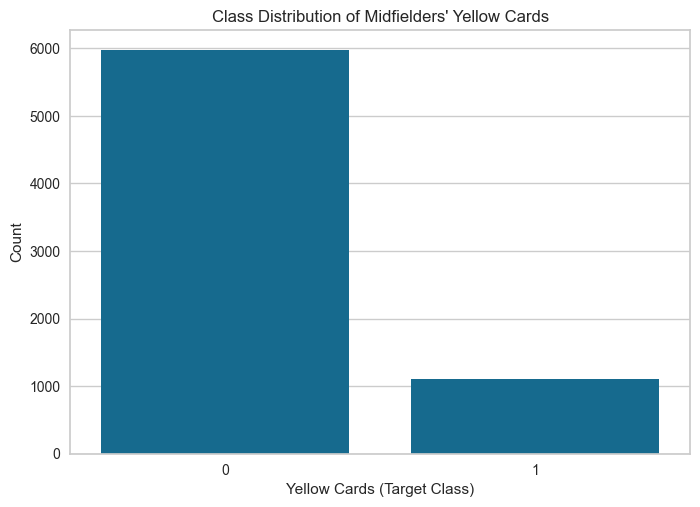

In [108]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [109]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 3956, number of negative: 3956
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012874 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23842
[LightGBM] [Info] Number of data points in the train set: 7912, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 116)"
4,Transformed data shape,"(10035, 24)"
5,Transformed train set shape,"(7912, 24)"
6,Transformed test set shape,"(2123, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


In [110]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5700,0.5914,0.5388,0.1902,0.2810,0.0653,0.0837,3.1800
lr,Logistic Regression,0.5700,0.5911,0.5375,0.1899,0.2805,0.0647,0.0829,3.8520
lda,Linear Discriminant Analysis,0.5698,0.5905,0.5388,0.1901,0.2809,0.0651,0.0835,1.8600
gbc,Gradient Boosting Classifier,0.8421,0.5884,0.0000,0.0000,0.0000,-0.0032,-0.0119,5.4860
nb,Naive Bayes,0.5146,0.5851,0.6384,0.1887,0.2912,0.0659,0.0947,1.2260
et,Extra Trees Classifier,0.8254,0.5806,0.0478,0.2294,0.0788,0.0255,0.0359,1.9790
qda,Quadratic Discriminant Analysis,0.5587,0.5751,0.5183,0.1807,0.2678,0.0473,0.0616,2.4100
lightgbm,Light Gradient Boosting Machine,0.8385,0.5707,0.0155,0.2680,0.0290,0.0104,0.0258,1.5940
ada,Ada Boost Classifier,0.8302,0.5669,0.0478,0.2713,0.0796,0.0341,0.0510,2.6520
svm,SVM - Linear Kernel,0.5385,0.5646,0.5659,0.1837,0.2759,0.0537,0.0730,2.7090


In [111]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [112]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5907,0.6268,0.5897,0.2120,0.3119,0.1047,0.1326
1,0.5685,0.5579,0.5385,0.1909,0.2819,0.0647,0.0825
2,0.5685,0.5779,0.5128,0.1852,0.2721,0.0534,0.0674
3,0.5556,0.5620,0.5000,0.1773,0.2617,0.0379,0.0484
4,0.5879,0.6598,0.6364,0.2178,0.3245,0.1207,0.1567
5,0.5414,0.5400,0.4416,0.1560,0.2305,0.0008,0.0010
6,0.5313,0.5293,0.4026,0.1429,0.2109,-0.0243,-0.0310
7,0.5939,0.6287,0.5584,0.2048,0.2997,0.0932,0.1165
8,0.5879,0.5973,0.5195,0.1932,0.2817,0.0710,0.0881


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [115]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.

## FWD


yellow_cards
0    1402
1     188
Name: count, dtype: int64


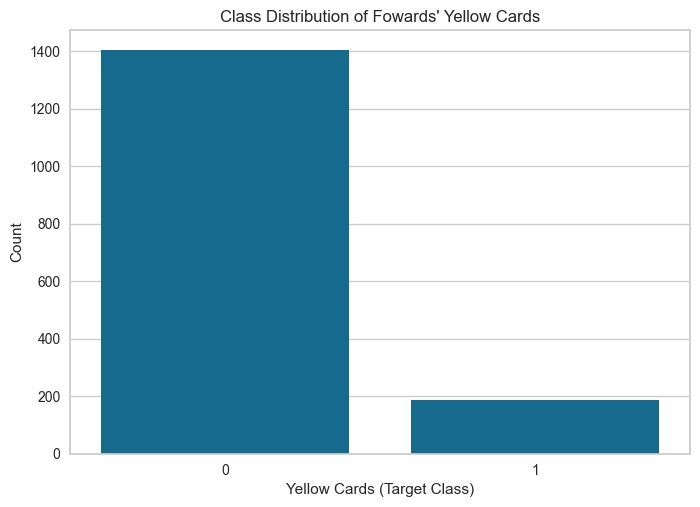

In [119]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [120]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 936, number of negative: 936
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.569254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22837
[LightGBM] [Info] Number of data points in the train set: 1872, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 116)"
4,Transformed data shape,"(2349, 24)"
5,Transformed train set shape,"(1872, 24)"
6,Transformed test set shape,"(477, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


In [121]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8635,0.5276,0.0000,0.0000,0.0000,-0.0313,-0.0462,1.2050
dt,Decision Tree Classifier,0.7628,0.5117,0.1824,0.1337,0.1534,0.0203,0.0205,0.8640
svm,SVM - Linear Kernel,0.5195,0.5025,0.5055,0.1241,0.1982,0.0108,0.0181,1.0300
ada,Ada Boost Classifier,0.8106,0.5013,0.0912,0.1019,0.0938,-0.0055,-0.0076,1.1920
dummy,Dummy Classifier,0.8814,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0420
et,Extra Trees Classifier,0.8733,0.4974,0.0071,0.0500,0.0125,-0.0044,-0.0072,1.2210
gbc,Gradient Boosting Classifier,0.8500,0.4895,0.0220,0.0556,0.0299,-0.0244,-0.0316,1.6160
lda,Linear Discriminant Analysis,0.5571,0.4863,0.4077,0.1133,0.1770,-0.0093,-0.0104,1.0400
ridge,Ridge Classifier,0.5508,0.4862,0.4231,0.1148,0.1802,-0.0064,-0.0063,0.8830
lr,Logistic Regression,0.5571,0.4837,0.4148,0.1144,0.1790,-0.0069,-0.0064,2.9850


In [122]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [123]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7679,0.4662,0.0769,0.0667,0.0714,-0.0605,-0.0607
1,0.6786,0.5160,0.2857,0.1333,0.1818,0.0137,0.0152
2,0.7857,0.5022,0.2143,0.1875,0.2000,0.0769,0.0772
3,0.8018,0.5628,0.0769,0.0909,0.0833,-0.0269,-0.0270
4,0.7568,0.4356,0.1538,0.1111,0.1290,-0.0081,-0.0082
5,0.7838,0.6750,0.3077,0.2105,0.2500,0.1288,0.1320
6,0.8108,0.6648,0.0000,0.0000,0.0000,-0.0980,-0.1015
7,0.7928,0.5604,0.0769,0.0833,0.0800,-0.0365,-0.0366
8,0.7387,0.4356,0.0769,0.0556,0.0645,-0.0827,-0.0842


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [124]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [126]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                              